<a href="https://colab.research.google.com/github/HafizRizqi/PCVK_2026/blob/main/Week5_Hafiz_TI3C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA : HAFIZ RIZQI HERNANDA
NIM : 244107020154 | N = 154
bipins : 32
clip   : 3.0
tile   : 4
L      : 4
WAKTU : 2026-10-01 11:47:08 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : a758ef3c42082f64


Text(0.5, 1.0, 'CLAH3.0')

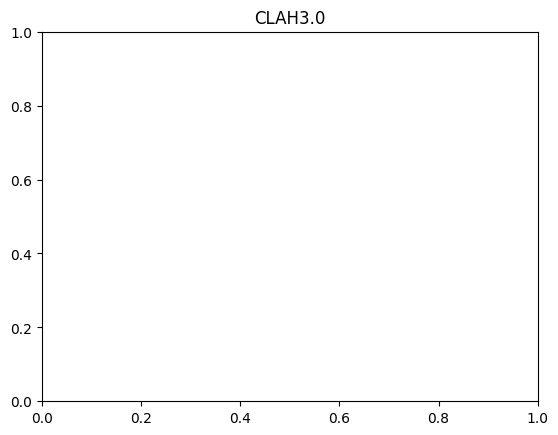

In [4]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'HAFIZ RIZQI HERNANDA'
NIM = '244107020154'
N = int(NIM[-3:])

PARAM = {
    'bipins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)

for k, v in PARAM.items():
    print('%-6s : %s' % (k, v))

print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())

kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

plt.title('CLAH' + str(PARAM['clip']))

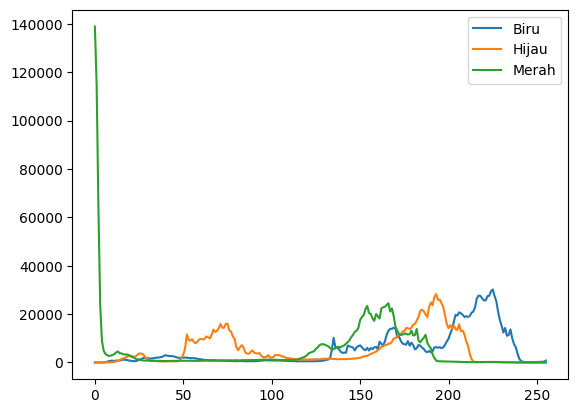

In [21]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/PCVK/'
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)  # 1. siapkan penghitung, isi 0

    for y in range(img.shape[0]):    # 2. telusuri setiap baris
        for x in range(img.shape[1]): # 2. dan setiap kolom
            h[img[y, x]] += 1        # 3. tambah 1 sesuai nilai piksel

    return h


gray = cv.imread(BASE + '/KTM1b.jpeg', cv.IMREAD_GRAYSCALE)

h = histogram_manual(gray)
p = h / gray.size                  # 4. normalisasi, jumlahnya = 1
cdf = p.cumsum()                   # 5. distribusi kumulatif

assert h.sum() == gray.size        # pemeriksaan wajib

# citra berwarna: ulangi untuk tiap kanal
bgr = cv.imread(BASE + '/KTM1d.jpeg')

for i, nama in enumerate(['Biru', 'Hijau', 'Merah']):
    plt.plot(histogram_manual(bgr[:, :, i]), label=nama)
    plt.legend()
plt.show()

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob


<BarContainer object of 256 artists>

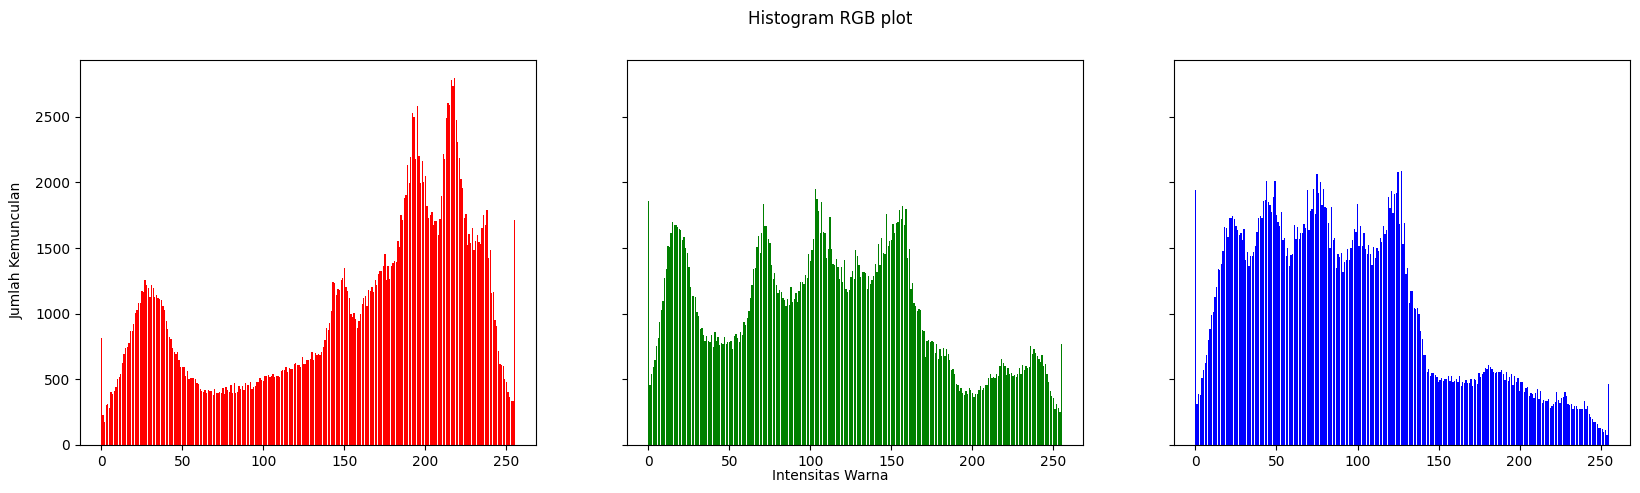

In [15]:
# membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height):
    for x in range(0,width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')


<BarContainer object of 256 artists>

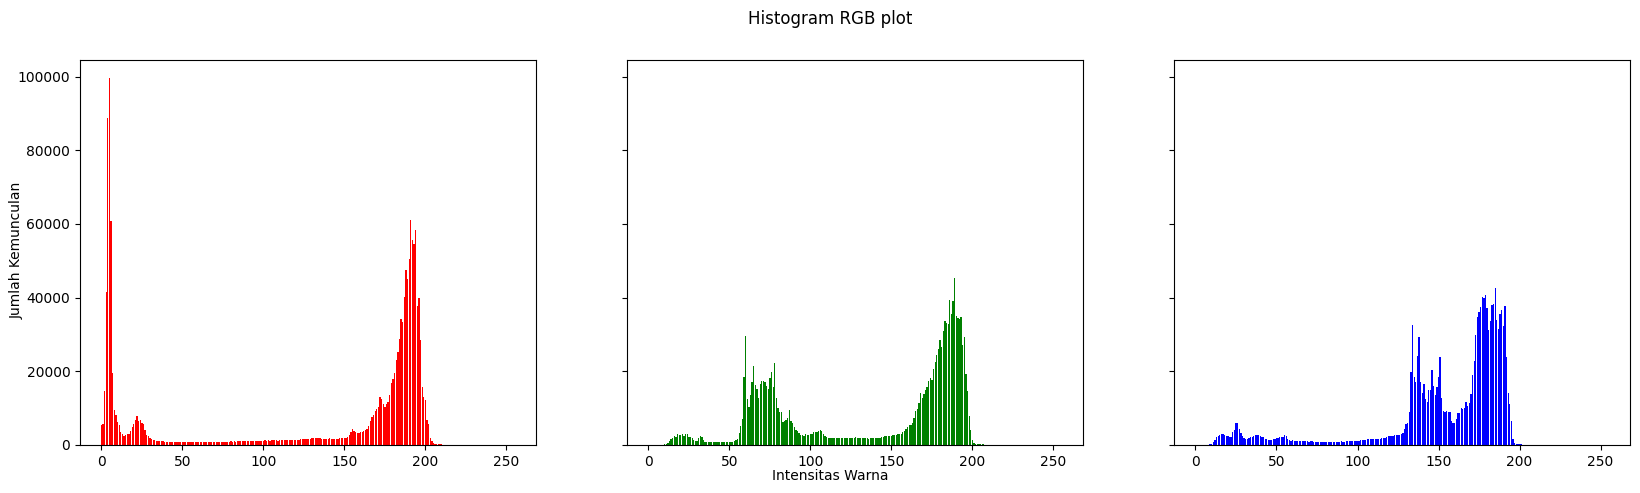

In [14]:
# membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/KTM1b.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height):
    for x in range(0,width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

Pertanyaan No.1 Pada Praktikum E1

In [7]:
#Membuat Fungsi Histogram Manual
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1

    return h

In [10]:
# Membaca gambar Lena
CONTOH = '/content/drive/MyDrive/'
gray = cv.imread(CONTOH + '/lena.jpg', cv.IMREAD_GRAYSCALE)

In [11]:
h = histogram_manual(gray)

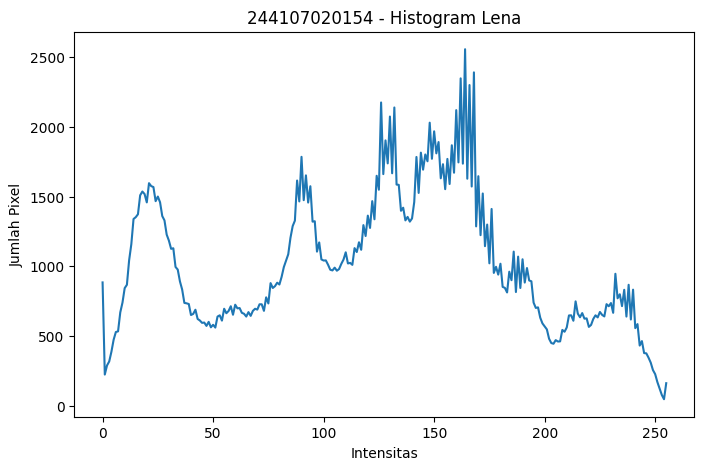

In [12]:
plt.figure(figsize=(8,5))
plt.plot(h)
plt.title(NIM + ' - Histogram Lena')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')
plt.show()

In [18]:
#Membuat Fungsi Histogram Manual
def histogram_manual(img, L=256):
    h_ktm = np.zeros(L, dtype=np.int64)

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h_ktm[img[y, x]] += 1

    return h_ktm

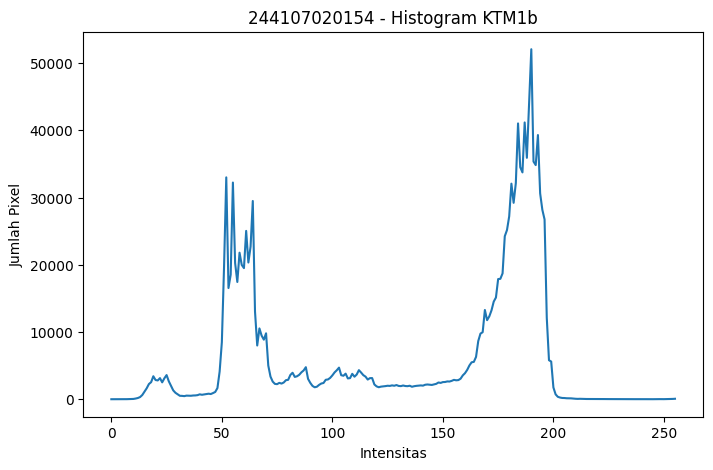

In [22]:
# Menggunakan Gambar KTM1b
gray_ktm = cv.imread(BASE + '/KTM1b.jpeg', cv.IMREAD_GRAYSCALE)

h_ktm = histogram_manual(gray_ktm)

plt.figure(figsize=(8,5))
plt.plot(h_ktm)
plt.title(NIM + ' - Histogram KTM1b')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')
plt.show()

Membandingkan histogram manual, NumPy, dan cv.calcHist pada Lena

In [23]:
h_manual = histogram_manual(gray)

In [24]:
h_numpy, edges = np.histogram(gray, bins=256, range=(0,256))

In [25]:
h_cv = cv.calcHist([gray], [0], None, [256], [0,256]).ravel()

In [26]:
print("Selisih manual vs numpy :", np.max(np.abs(h_manual - h_numpy)))
print("Selisih manual vs cv    :", np.max(np.abs(h_manual - h_cv)))
print("Selisih numpy vs cv     :", np.max(np.abs(h_numpy - h_cv)))

Selisih manual vs numpy : 0
Selisih manual vs cv    : 0.0
Selisih numpy vs cv     : 0.0


Membandingkan histogram manual, NumPy, dan cv.calcHist pada KTM1b

In [27]:
h_ktm_Manual = histogram_manual(gray_ktm)

In [28]:
h_ktm_numpy, edges = np.histogram(gray_ktm, bins=256, range=(0,256))

In [29]:
h_ktm_cv = cv.calcHist([gray_ktm], [0], None, [256], [0,256]).ravel()

In [30]:
print("Selisih manual vs numpy :", np.max(np.abs(h_ktm_Manual - h_ktm_numpy)))
print("Selisih manual vs cv    :", np.max(np.abs(h_ktm_Manual - h_ktm_cv)))
print("Selisih numpy vs cv     :", np.max(np.abs(h_ktm_numpy - h_ktm_cv)))

Selisih manual vs numpy : 0
Selisih manual vs cv    : 0.0
Selisih numpy vs cv     : 0.0


Pertanyaan No.2 Pada Praktikum E1

In [33]:
# Buat daftar File
files = ['KTM1a.jpeg', 'KTM1b.jpeg', 'KTM1c.jpeg', 'KTM1d.jpeg']

In [34]:
# Baca masing-masing citra grayscale
images = []

for f in files:
    img = cv.imread(BASE + '/' + f, cv.IMREAD_GRAYSCALE)
    images.append(img)

In [35]:
# Hitung histogram
h = histogram_manual(img)
# Normalisasi Histogram
p = h / img.size
# Hitung CDF
cdf = np.cumsum(p)


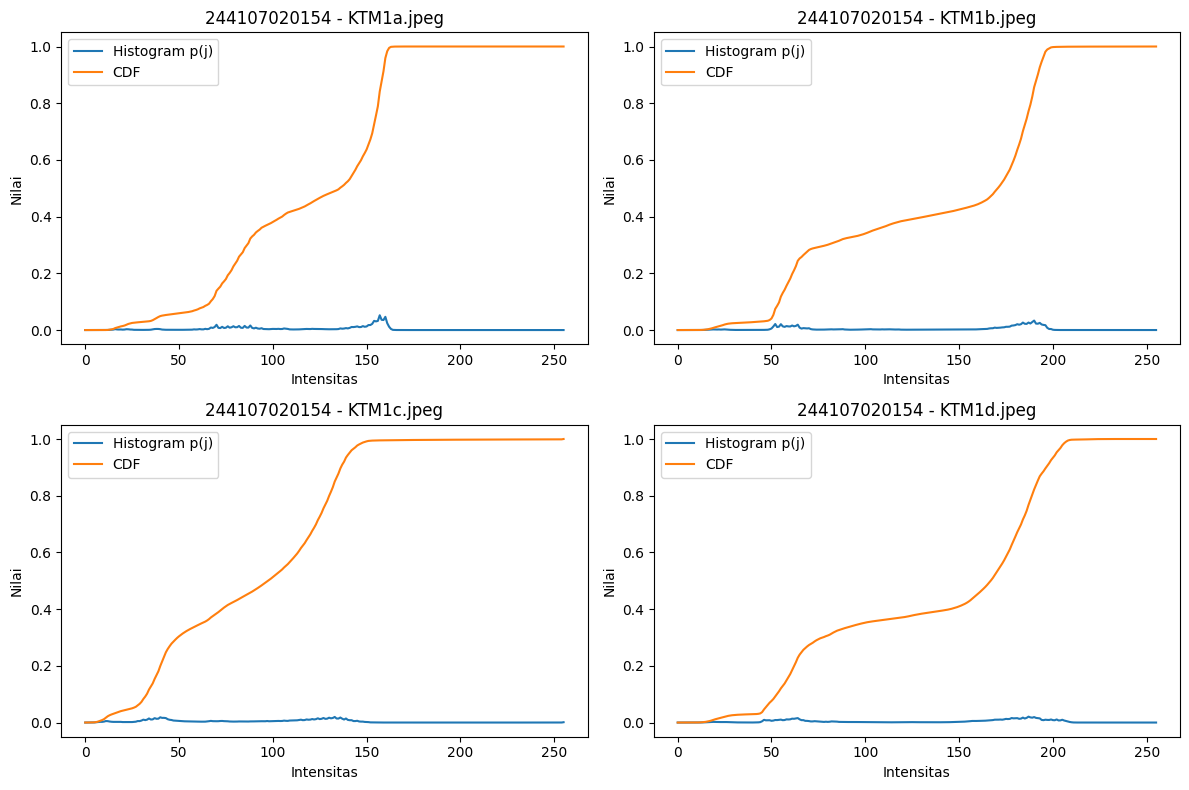

In [36]:
# Buat figure 2x2
plt.figure(figsize=(12,8))

for i, (img, f) in enumerate(zip(images, files), 1):
    h = histogram_manual(img)
    p = h / img.size
    cdf = np.cumsum(p)

    plt.subplot(2,2,i)
    plt.plot(np.arange(256), p, label='Histogram p(j)')
    plt.plot(np.arange(256), cdf, label='CDF')
    plt.title(NIM + ' - ' + f)
    plt.xlabel('Intensitas')
    plt.ylabel('Nilai')
    plt.legend()

plt.tight_layout()
plt.show()

Pertanyaan No.3 Pada Praktikum E1

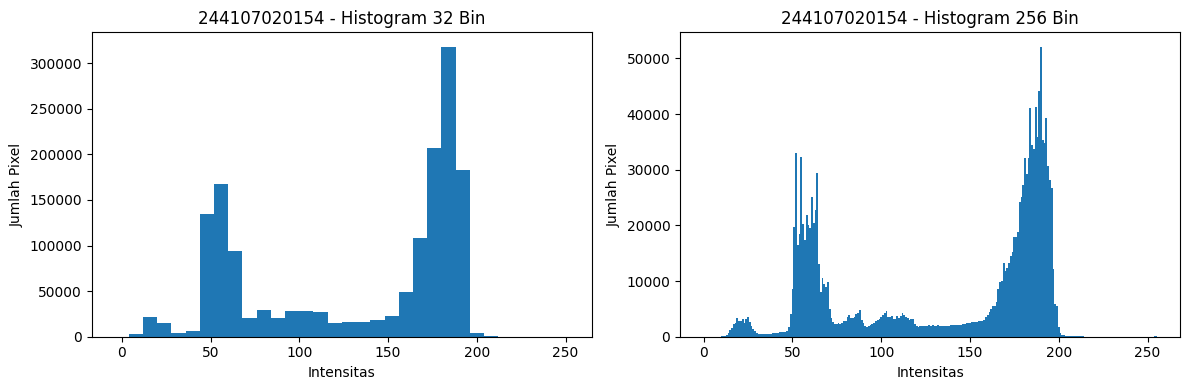

In [41]:
img = cv.imread(BASE + '/KTM1b.jpeg', cv.IMREAD_GRAYSCALE)

PARAM = {
    'bins': 32   # jumlah bin
}
# Histogram 32 bin
hist32, edge32 = np.histogram(
    img,
    bins=PARAM['bins'],
    range=(0,256)
)
# Histogram 256 bin
hist256, edge256 = np.histogram(
    img,
    bins=256,
    range=(0,256)
)
# Menampilkan
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.bar(edge32[:-1], hist32, width=8)
plt.title(NIM + ' - Histogram 32 Bin')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.subplot(1,2,2)
plt.bar(edge256[:-1], hist256, width=1)
plt.title(NIM + ' - Histogram 256 Bin')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

PERCOBAAN PRAKTIKUM E2

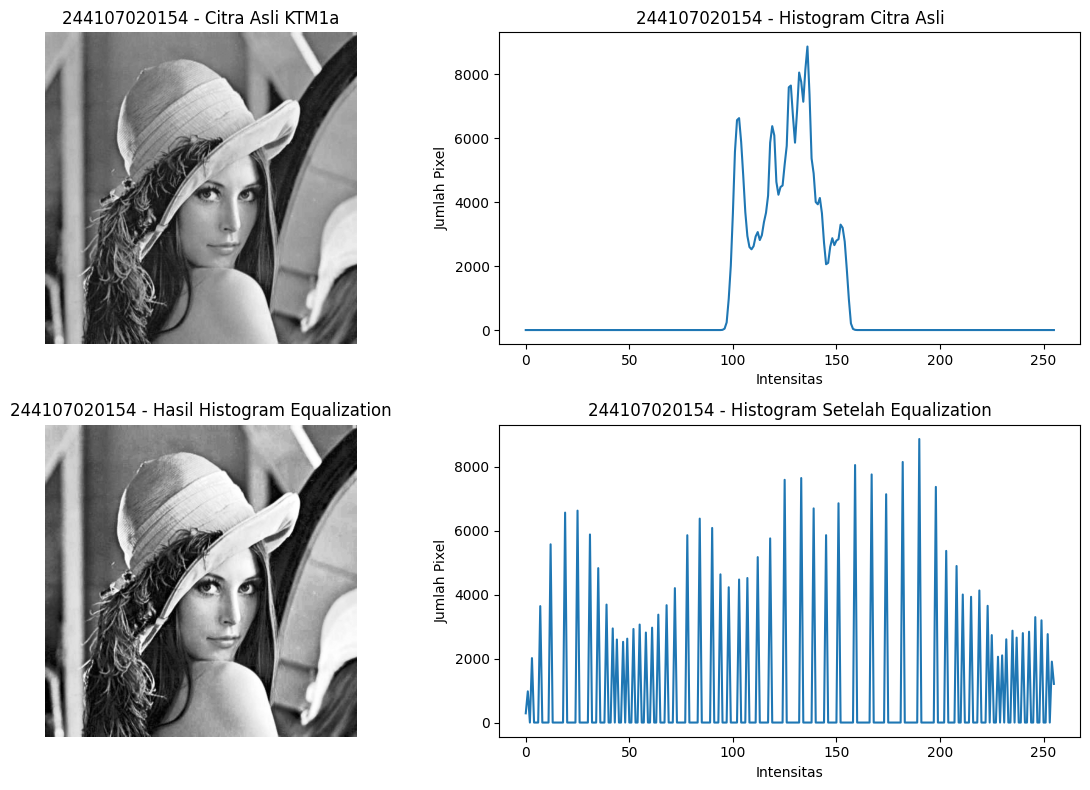

In [48]:
# NOMOR 1
# Tahap 1
img = cv.imread(CONTOH + '/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
hist = histogram_manual(img)
prob = hist / img.size
cdf = np.cumsum(prob)

L = 256
transform = np.round((L - 1) * cdf).astype(np.uint8)
hasil_manual = transform[img]

hist_asli = cv.calcHist(
    [img], [0], None, [256], [0, 256]
)
hist_equal = cv.calcHist(
    [hasil_manual], [0], None, [256], [0, 256]
)
plt.figure(figsize=(12, 8))
# Citra asli
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title(NIM + ' - Citra Asli KTM1a')
plt.axis('off')

# Histogram asli
plt.subplot(2, 2, 2)
plt.plot(hist_asli)
plt.title(NIM + ' - Histogram Citra Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

# Citra hasil equalization
plt.subplot(2, 2, 3)
plt.imshow(hasil_manual, cmap='gray')
plt.title(NIM + ' - Hasil Histogram Equalization')
plt.axis('off')

# Histogram hasil equalization
plt.subplot(2, 2, 4)
plt.plot(hist_equal)
plt.title(NIM + ' - Histogram Setelah Equalization')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

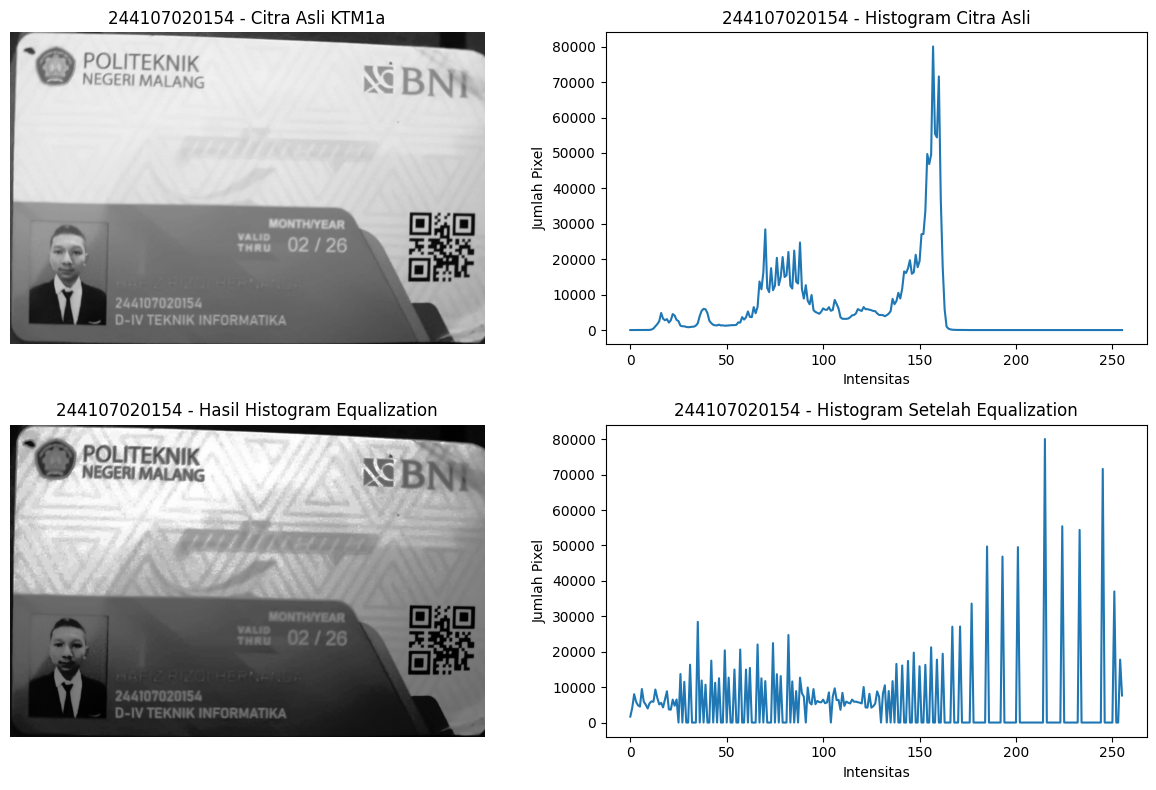

In [49]:
img = cv.imread(BASE + '/KTM1a.jpeg', cv.IMREAD_GRAYSCALE)
hist = histogram_manual(img)
prob = hist / img.size
cdf = np.cumsum(prob)

L = 256
transform = np.round((L - 1) * cdf).astype(np.uint8)
hasil_manual = transform[img]

hist_asli = cv.calcHist(
    [img], [0], None, [256], [0, 256]
)
hist_equal = cv.calcHist(
    [hasil_manual], [0], None, [256], [0, 256]
)
plt.figure(figsize=(12, 8))
# Citra asli
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title(NIM + ' - Citra Asli KTM1a')
plt.axis('off')

# Histogram asli
plt.subplot(2, 2, 2)
plt.plot(hist_asli)
plt.title(NIM + ' - Histogram Citra Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

# Citra hasil equalization
plt.subplot(2, 2, 3)
plt.imshow(hasil_manual, cmap='gray')
plt.title(NIM + ' - Hasil Histogram Equalization')
plt.axis('off')

# Histogram hasil equalization
plt.subplot(2, 2, 4)
plt.plot(hist_equal)
plt.title(NIM + ' - Histogram Setelah Equalization')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

# Nomor 2